# Camada Ouro: previsão origem-destino - LightGBM

**Modelagem**

**Desafio 3 — Próximo Trecho:** LightGBM multiclasse para prever o par
  origem-destino mais provável.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import holidays
import sys

!git clone https://github.com/vsmacedo-datafinance/Challenge_ClickBus_FIAP_2025.git

sys.path.append('/content/Challenge_ClickBus_FIAP_2025')
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/Portifólio DS Vini/Challenge_ClickBus_2025/data"

df_treino = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_treino.parquet")
df_val   = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_val.parquet")
df_teste = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_teste.parquet")

df_treino = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_treino.parquet")

Cloning into 'Challenge_ClickBus_FIAP_2025'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 87 (delta 21), reused 28 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 11.29 MiB | 14.18 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Mounted at /content/drive


In [ ]:
df_treino.head()

,nk_ota_localizer_id,data_compra,time_purchase,gmv_success,quantidade_tickets,origem_ida,destino_ida,origem_volta,destino_volta,empresa_ida,...,compra_ate_5_dias_feriado,hora_compra,periodo_compra,trecho_ida,trecho_volta_valido,mesma_empresa_ida_volta,mesmo_trecho_ida_volta,combinacao_empresa,faixa_tickets,split
0,411af9474e73be133816d26112dbbeb77f3f3e0cf96391...,2013-09-12,16:04:22,65.63,1,Cidade_17,Cidade_132,0,0,Empresa_35,...,0,16,Tarde,Cidade_17 -> Cidade_132,Sem Volta,0,0,Empresa_35 + Empresa_299,1 Ticket,train
1,9fdac511b94015d5c72d05fe1f8987ed9556beee24b5cf...,2013-09-13,14:37:45,164.78,2,Cidade_2,Cidade_17,0,0,Empresa_8,...,0,14,Tarde,Cidade_2 -> Cidade_17,Sem Volta,1,0,Empresa_8 + Empresa_8,2 Tickets,train
2,57f393dbde0d437a85a5d4ee586f5ca24a394740d3e1b7...,2013-09-17,16:28:09,81.62,1,Cidade_17,Cidade_2,0,0,Empresa_2,...,0,16,Tarde,Cidade_17 -> Cidade_2,Sem Volta,0,0,Empresa_2 + Empresa_299,1 Ticket,train
3,13d789d4960c739a15a4337d518eca32d197e9aa17b6c3...,2013-09-18,12:41:05,46.42,1,Cidade_0,Cidade_65,0,0,Empresa_13,...,0,12,Tarde,Cidade_0 -> Cidade_65,Sem Volta,0,0,Empresa_13 + Empresa_299,1 Ticket,train
4,7832c18fa62d33b54da85438fd7e7bb7a10a6ca923665e...,2013-09-19,20:24:01,79.30,1,Cidade_106,Cidade_2,0,0,Empresa_2,...,0,20,Noite,Cidade_106 -> Cidade_2,Sem Volta,0,0,Empresa_2 + Empresa_299,1 Ticket,train


In [ ]:
df_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214036 entries, 0 to 1214035
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   nk_ota_localizer_id        1214036 non-null  object        
 1   data_compra                1214036 non-null  datetime64[ns]
 2   time_purchase              1214036 non-null  object        
 3   gmv_success                1214036 non-null  float64       
 4   quantidade_tickets         1214036 non-null  int16         
 5   origem_ida                 1214036 non-null  object        
 6   destino_ida                1214036 non-null  object        
 7   origem_volta               1214036 non-null  object        
 8   destino_volta              1214036 non-null  object        
 9   empresa_ida                1214036 non-null  object        
 10  empresa_volta              1214036 non-null  object        
 11  id_cliente                 1214036 no

In [ ]:
df_treino.shape

(1214036, 29)

# Análise Exploratória EDA

## Ticket

In [ ]:
df_treino['quantidade_tickets'].value_counts()

,count
quantidade_tickets,
1,874596
2,270070
4,36047
3,24003
6,4059
5,2996
8,1612
10,594
12,22


In [ ]:
tickets_por_cliente = df_treino.groupby('id_cliente')['quantidade_tickets'].sum().reset_index()
tickets_por_cliente.columns = ['id_cliente', 'total_tickets']
print(tickets_por_cliente['total_tickets'].describe())

count    462800.000000
mean          3.651048
std           9.313625
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1977.000000
Name: total_tickets, dtype: float64


In [ ]:
# Analise de Outliers para compras feitas por clientes unicos
Q1 = tickets_por_cliente['total_tickets'].quantile(0.25)
Q3 = tickets_por_cliente['total_tickets'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")
print(f"Limite inferior para outliers (Q3 + 1.5*IQR): {limite_inferior}")
print(f"Limite superior para outliers (Q3 + 1.5*IQR): {limite_superior}")

outliers = tickets_por_cliente[(tickets_por_cliente['total_tickets'] < limite_inferior) | (tickets_por_cliente['total_tickets'] > limite_superior)]
print(f"\nOutliers (acima de {limite_superior:.1f} tickets): {len(outliers)} compras")
print(f"Percentual de outliers: {len(outliers)/len(tickets_por_cliente)*100:.2f}%")

print(f"\nDistribuição de quantidade de tickets:")
freq_tickets = tickets_por_cliente['total_tickets'].value_counts().sort_index()
for valor, freq in freq_tickets.head(10).items():
    percentual = (freq / len(tickets_por_cliente)) * 100
    print(f"{valor} tickets: {freq:,} compras ({percentual:.2f}%)")

Q1 (25%): 1.0
Q3 (75%): 4.0
IQR: 3.0
Limite inferior para outliers (Q3 + 1.5*IQR): -3.5
Limite superior para outliers (Q3 + 1.5*IQR): 8.5

Outliers (acima de 8.5 tickets): 36033 compras
Percentual de outliers: 7.79%

Distribuição de quantidade de tickets:
1 tickets: 172,539 compras (37.28%)
2 tickets: 119,029 compras (25.72%)
3 tickets: 40,097 compras (8.66%)
4 tickets: 43,788 compras (9.46%)
5 tickets: 16,670 compras (3.60%)
6 tickets: 16,750 compras (3.62%)
7 tickets: 8,827 compras (1.91%)
8 tickets: 9,067 compras (1.96%)
9 tickets: 5,303 compras (1.15%)
10 tickets: 5,024 compras (1.09%)


In [ ]:
from src.utils import analisar_feriados_projeto

top_feriados, proximo_feriado, dias_ate_feriado = analisar_feriados_projeto(
    df_treino=df_treino,
    data_corte=df_treino['data_compra'].max()  # usa o corte real do treino
)

print(f"--- Top 10 Feriados por GMV Médio Anual ---\n")
display(top_feriados.head(10))

print(f"\n--- Contexto Temporal ---")
print(f"Corte do treino     : {df_treino['data_compra'].max().date()}")
print(f"Próximo feriado     : {proximo_feriado}")
print(f"Dias até o feriado  : {dias_ate_feriado}")

--- Top 10 Feriados por GMV Médio Anual ---



,gmv_medio_anual,compras_medias_anual,tickets_medios_anual,anos_ocorreu
nome_feriado,,,,
Christmas Day,75684.63,505.56,729.89,9
Universal Fraternization Day,72573.75,509.00,727.00,9
Republic Proclamation Day,60743.48,429.60,587.40,10
Independence Day,59674.48,414.12,562.88,8
Our Lady of Aparecida,52455.12,375.00,508.10,10
All Souls' Day,46824.58,323.40,447.60,10
Tiradentes' Day,43245.02,303.56,407.67,9
Good Friday,39242.30,286.33,383.78,9
Worker's Day,37142.81,284.33,367.56,9



--- Contexto Temporal ---
Corte do treino     : 2022-12-18
Próximo feriado     : 2022-12-25
Dias até o feriado  : 7


<Axes: xlabel='dia_semana'>

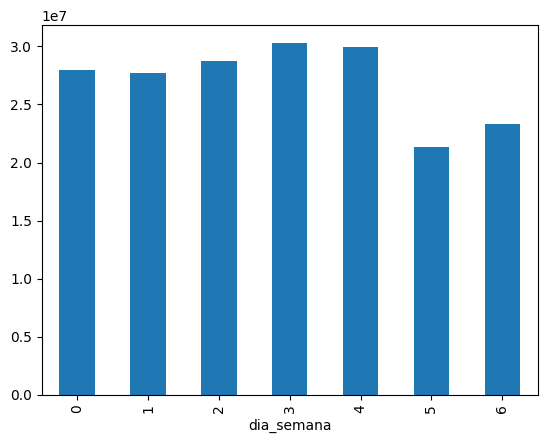

In [ ]:
df_treino.groupby('mes')['gmv_success'].sum().plot(kind='bar')
df_treino.groupby('dia_semana')['gmv_success'].sum().plot(kind='bar')

## Trechos

In [ ]:
top_trechos = df_treino['trecho_ida'].value_counts()
print(top_trechos)

trecho_ida
Cidade_0 -> Cidade_2          26219
Cidade_2 -> Cidade_0          24974
Cidade_0 -> Cidade_65         14752
Cidade_0 -> Cidade_5          13787
Cidade_5 -> Cidade_0          12400
                              ...  
Cidade_748 -> Cidade_63           1
Cidade_499 -> Cidade_804          1
Cidade_2007 -> Cidade_1042        1
Cidade_367 -> Cidade_753          1
Cidade_1711 -> Cidade_97          1
Name: count, Length: 29326, dtype: int64


In [ ]:
market_share = df_treino['empresa_ida'].value_counts(normalize=True).head(10) * 100
fidelidade = df_treino['mesma_empresa_ida_volta'].value_counts(normalize=True)
print(market_share)
print('\n')
print(fidelidade)

empresa_ida
Empresa_8     11.054862
Empresa_24     5.660952
Empresa_13     4.981977
Empresa_6      4.839972
Empresa_2      4.437348
Empresa_12     2.949254
Empresa_23     2.870426
Empresa_17     2.570352
Empresa_3      2.563515
Empresa_11     2.385844
Name: proportion, dtype: float64


mesma_empresa_ida_volta
0    0.906514
1    0.093486
Name: proportion, dtype: float64


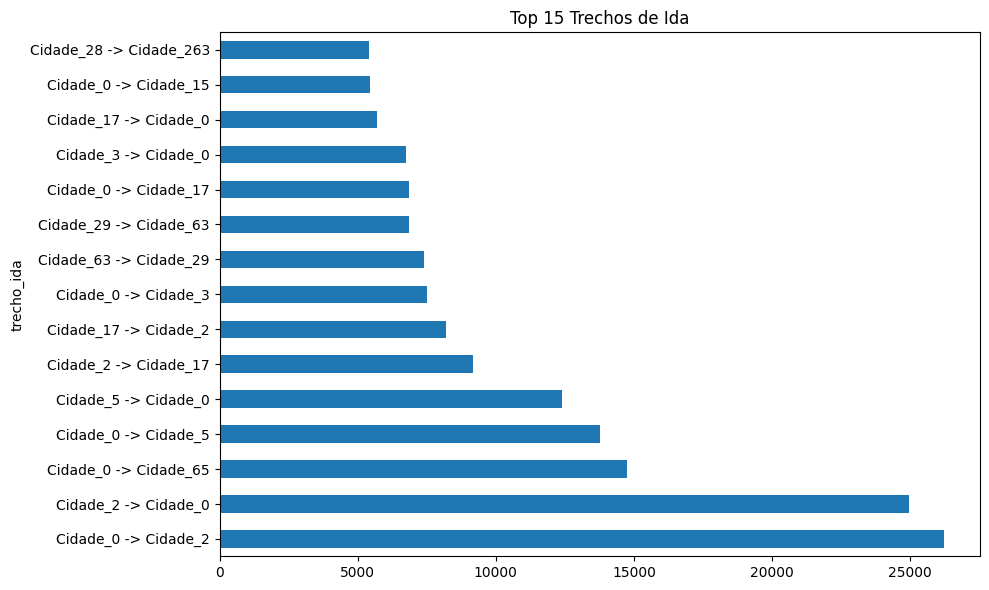

Trechos que respondem por 80% das vendas: 2209 de 29326


In [ ]:
top_trechos = df_treino['trecho_ida'].value_counts().head(15)
top_trechos.plot(kind='barh', figsize=(10,6), title='Top 15 Trechos de Ida')
plt.tight_layout(); plt.show()

# Concentração: Regra de Pareto
trechos_freq = df_treino['trecho_ida'].value_counts(normalize=True).cumsum()
n_trechos_80 = (trechos_freq <= 0.80).sum()
print(f"Trechos que respondem por 80% das vendas: {n_trechos_80} de {trechos_freq.shape[0]}")

pop_map = df_treino['trecho_ida'].value_counts()

df_treino['popularidade_trecho'] = df_treino['trecho_ida'].map(pop_map)
df_val['popularidade_trecho']   = df_val['trecho_ida'].map(pop_map).fillna(0)
df_teste['popularidade_trecho'] = df_teste['trecho_ida'].map(pop_map).fillna(0)

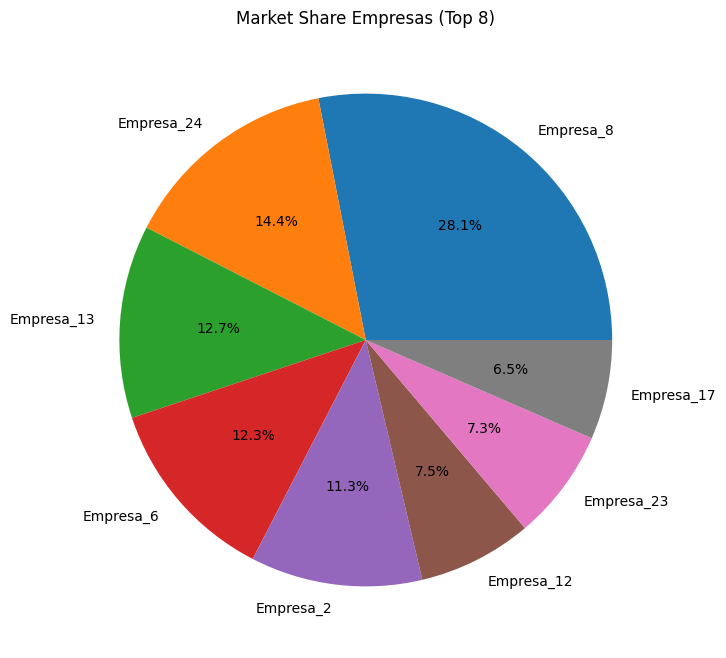

Clientes que usam mesma empresa ida e volta: 9.3%


In [ ]:
# Market share top 8
market_share = df_treino['empresa_ida'].value_counts(normalize=True).head(8) * 100
market_share.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8),
                  title='Market Share Empresas (Top 8)')
plt.ylabel(''); plt.show()

# Fidelidade ida/volta
fidelidade_rate = df_treino['mesma_empresa_ida_volta'].mean() * 100
print(f"Clientes que usam mesma empresa ida e volta: {fidelidade_rate:.1f}%")

In [ ]:
gmv_empresa = df_treino.groupby('empresa_ida')['gmv_success'].agg(['mean','count','sum'])
gmv_empresa.columns = ['gmv_medio', 'n_vendas', 'gmv_total']
print(gmv_empresa.sort_values('gmv_total', ascending=False).head(10))

              gmv_medio  n_vendas     gmv_total
empresa_ida                                    
Empresa_8    130.927388    134210  1.757176e+07
Empresa_24   156.098834     68726  1.072805e+07
Empresa_6    168.450540     58759  9.897985e+06
Empresa_2    180.146509     53871  9.704673e+06
Empresa_13   133.141527     60483  8.052799e+06
Empresa_23   221.988419     34848  7.735852e+06
Empresa_17   214.373737     31205  6.689532e+06
Empresa_5    257.984722     23143  5.970540e+06
Empresa_11   205.738884     28965  5.959227e+06
Empresa_19   243.572638     20234  4.928449e+06


In [ ]:
covid_resumo = df_treino.groupby('periodo_covid').agg(
    gmv_total    = ('gmv_success', 'sum'),
    gmv_medio    = ('gmv_success', 'mean'),
    n_compras    = ('gmv_success', 'count'),
    ticket_medio = ('quantidade_tickets', 'mean')
).round(2)
print(covid_resumo)

                  gmv_total  gmv_medio  n_compras  ticket_medio
periodo_covid                                                  
durante-covid  1.109641e+08     156.08     710966          1.38
pre-covid      7.841216e+07     155.87     503070          1.41


**Observação:** Devico o corte temporal para separação dos dados, o período pós covid não foi imputado dentro da base de treino

## Temporal

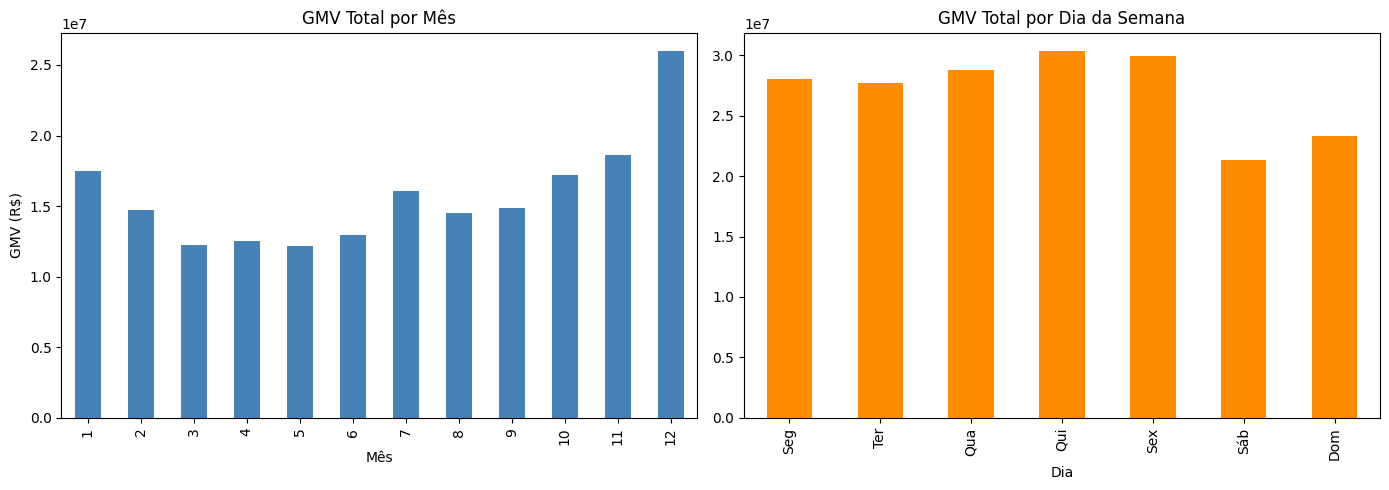

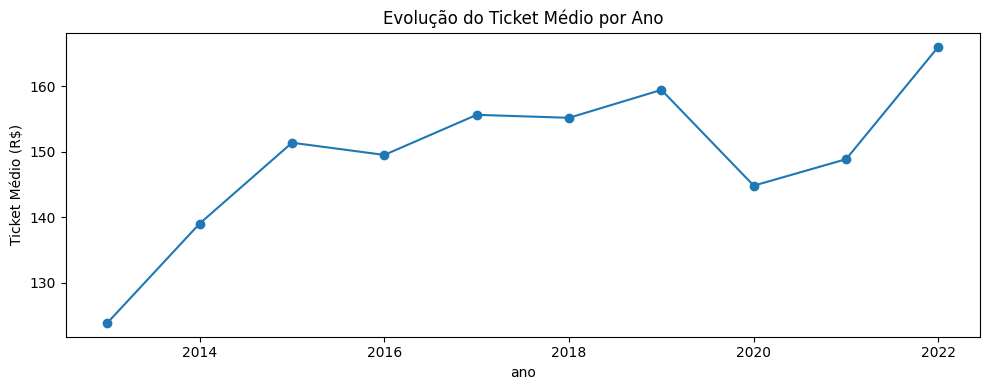

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gmv_mes = df_treino.groupby('mes')['gmv_success'].sum()
gmv_mes.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('GMV Total por Mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('GMV (R$)')

gmv_dia = df_treino.groupby('dia_semana')['gmv_success'].sum()
gmv_dia.index = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
gmv_dia.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('GMV Total por Dia da Semana')
axes[1].set_xlabel('Dia')

plt.tight_layout(); plt.show()

ticket_ano = df_treino.groupby('ano')['gmv_success'].mean()
ticket_ano.plot(marker='o', figsize=(10, 4), title='Evolução do Ticket Médio por Ano')
plt.ylabel('Ticket Médio (R$)'); plt.tight_layout(); plt.show()

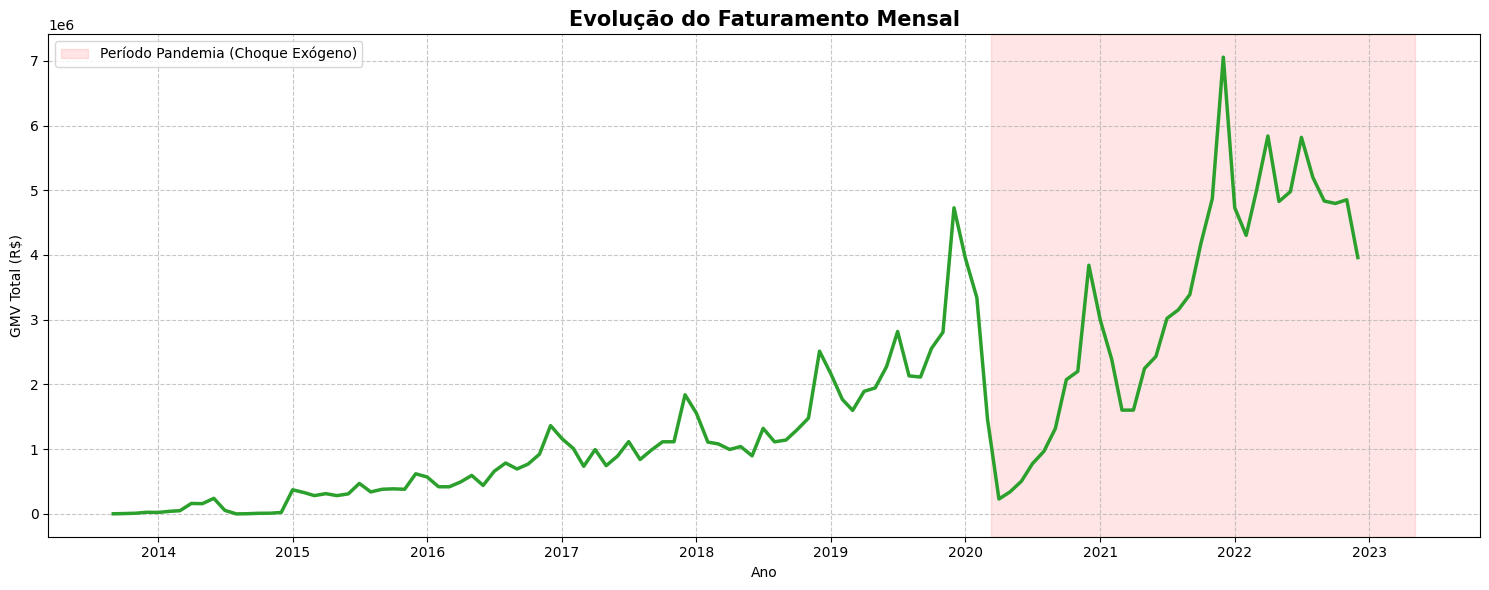

In [ ]:
from src.utils import INICIO_COVID, FIM_COVID

gmv_mensal_cont = df_treino.groupby(df_treino['data_compra'].dt.to_period('M'))['gmv_success'].sum().reset_index()
gmv_mensal_cont['data_compra'] = gmv_mensal_cont['data_compra'].dt.to_timestamp()

plt.figure(figsize=(15,6))
sns.lineplot(data=gmv_mensal_cont, x='data_compra', y='gmv_success', linewidth=2.5, color='#2ca02c')

plt.axvspan(INICIO_COVID, FIM_COVID, color='red', alpha=0.1, label='Período Pandemia (Choque Exógeno)')

plt.title('Evolução do Faturamento Mensal', fontweight='bold', fontsize=15)
plt.xlabel('Ano')
plt.ylabel('GMV Total (R$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

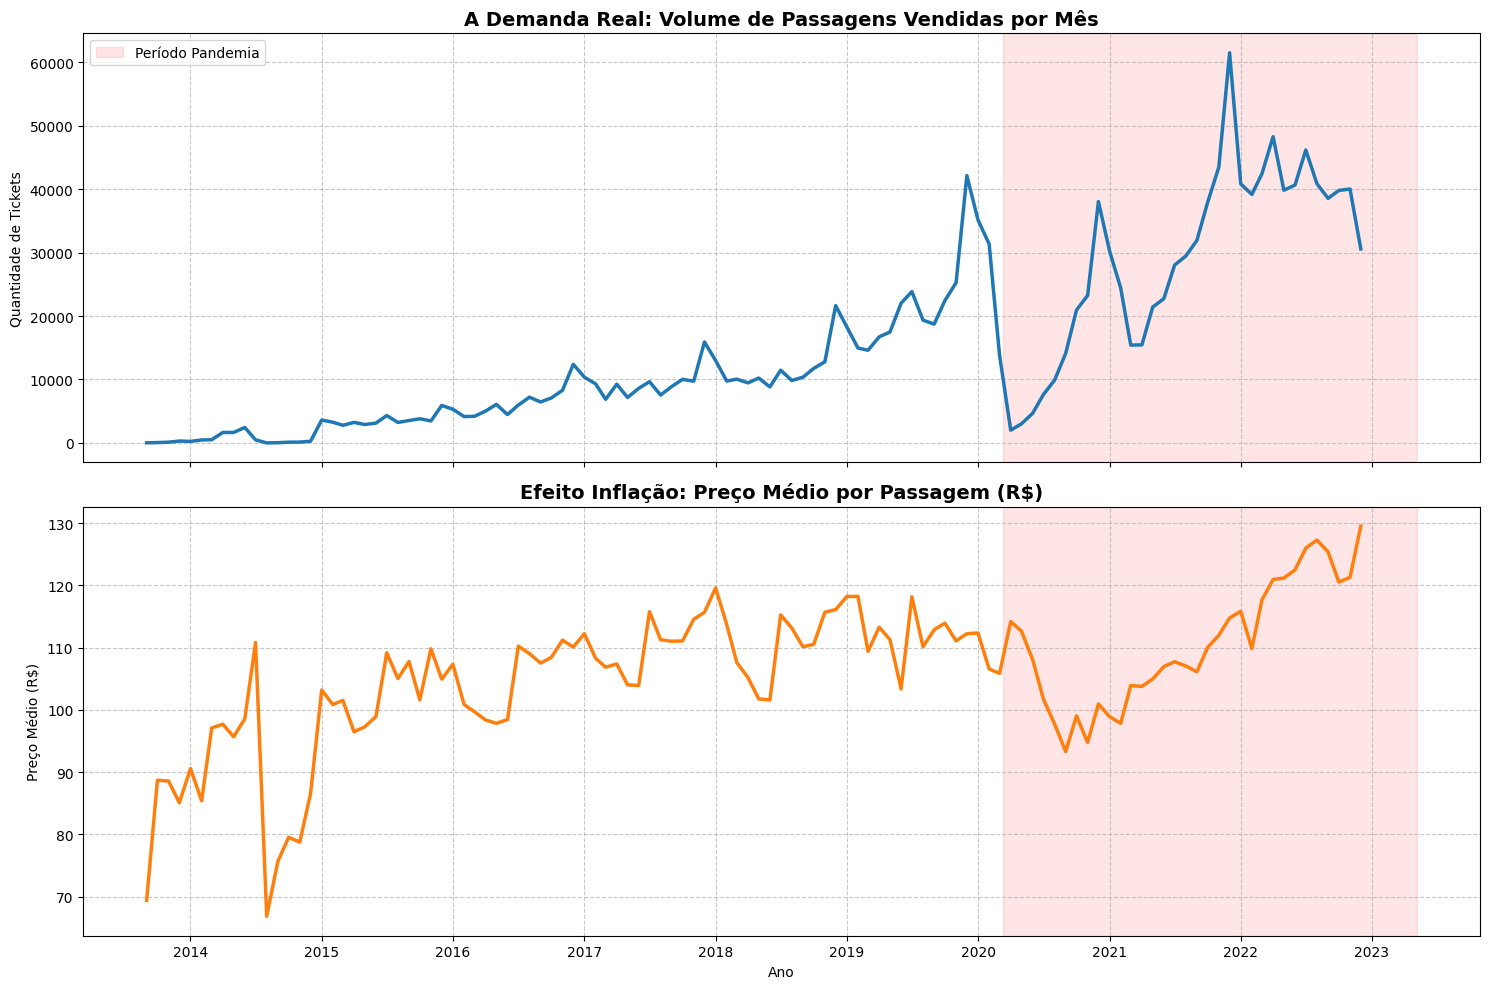

In [ ]:
evolucao_mensal = df_treino.groupby(df_treino['data_compra'].dt.to_period('M')).agg(
    gmv_total=('gmv_success', 'sum'),
    tickets_totais=('quantidade_tickets', 'sum')
).reset_index()

evolucao_mensal['data_compra'] = evolucao_mensal['data_compra'].dt.to_timestamp()
evolucao_mensal['preco_medio_passagem'] = evolucao_mensal['gmv_total'] / evolucao_mensal['tickets_totais']

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Volume de passagens
sns.lineplot(data=evolucao_mensal, x='data_compra', y='tickets_totais', ax=axes[0], color='#1f77b4', linewidth=2.5)
axes[0].axvspan(INICIO_COVID, FIM_COVID, color='red', alpha=0.1, label='Período Pandemia')
axes[0].set_title('A Demanda Real: Volume de Passagens Vendidas por Mês', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Quantidade de Tickets')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Preço médio ao decorrer do tempo
sns.lineplot(data=evolucao_mensal, x='data_compra', y='preco_medio_passagem', ax=axes[1], color='#ff7f0e', linewidth=2.5)
axes[1].axvspan(INICIO_COVID, FIM_COVID, color='red', alpha=0.1)
axes[1].set_title('Efeito Inflação: Preço Médio por Passagem (R$)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Preço Médio (R$)')
axes[1].set_xlabel('Ano')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214036 entries, 0 to 1214035
Data columns (total 30 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   nk_ota_localizer_id        1214036 non-null  object        
 1   data_compra                1214036 non-null  datetime64[ns]
 2   time_purchase              1214036 non-null  object        
 3   gmv_success                1214036 non-null  float64       
 4   quantidade_tickets         1214036 non-null  int16         
 5   origem_ida                 1214036 non-null  object        
 6   destino_ida                1214036 non-null  object        
 7   origem_volta               1214036 non-null  object        
 8   destino_volta              1214036 non-null  object        
 9   empresa_ida                1214036 non-null  object        
 10  empresa_volta              1214036 non-null  object        
 11  id_cliente                 1214036 no

In [ ]:
var_num = df_treino.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns.tolist()
var_cat = df_treino.select_dtypes(include=['object', 'category']).columns.tolist()
var_data = df_treino.select_dtypes(include=['datetime64']).columns.tolist()

print(f'Variaveis numéricas: ({len(var_num)}): {var_num}')
print(f'Variáveis categóricas: ({len(var_cat)}: {var_cat}')
print(f'Variáveis de data: ({len(var_data)}: {var_data}')

Variaveis numéricas: (13): ['gmv_success', 'quantidade_tickets', 'ano', 'mes', 'dia', 'dia_semana', 'fim_de_semana', 'e_feriado', 'compra_ate_5_dias_feriado', 'hora_compra', 'mesma_empresa_ida_volta', 'mesmo_trecho_ida_volta', 'popularidade_trecho']
Variáveis categóricas: (16: ['nk_ota_localizer_id', 'time_purchase', 'origem_ida', 'destino_ida', 'origem_volta', 'destino_volta', 'empresa_ida', 'empresa_volta', 'id_cliente', 'periodo_covid', 'periodo_compra', 'trecho_ida', 'trecho_volta_valido', 'combinacao_empresa', 'faixa_tickets', 'split']
Variáveis de data: (1: ['data_compra']


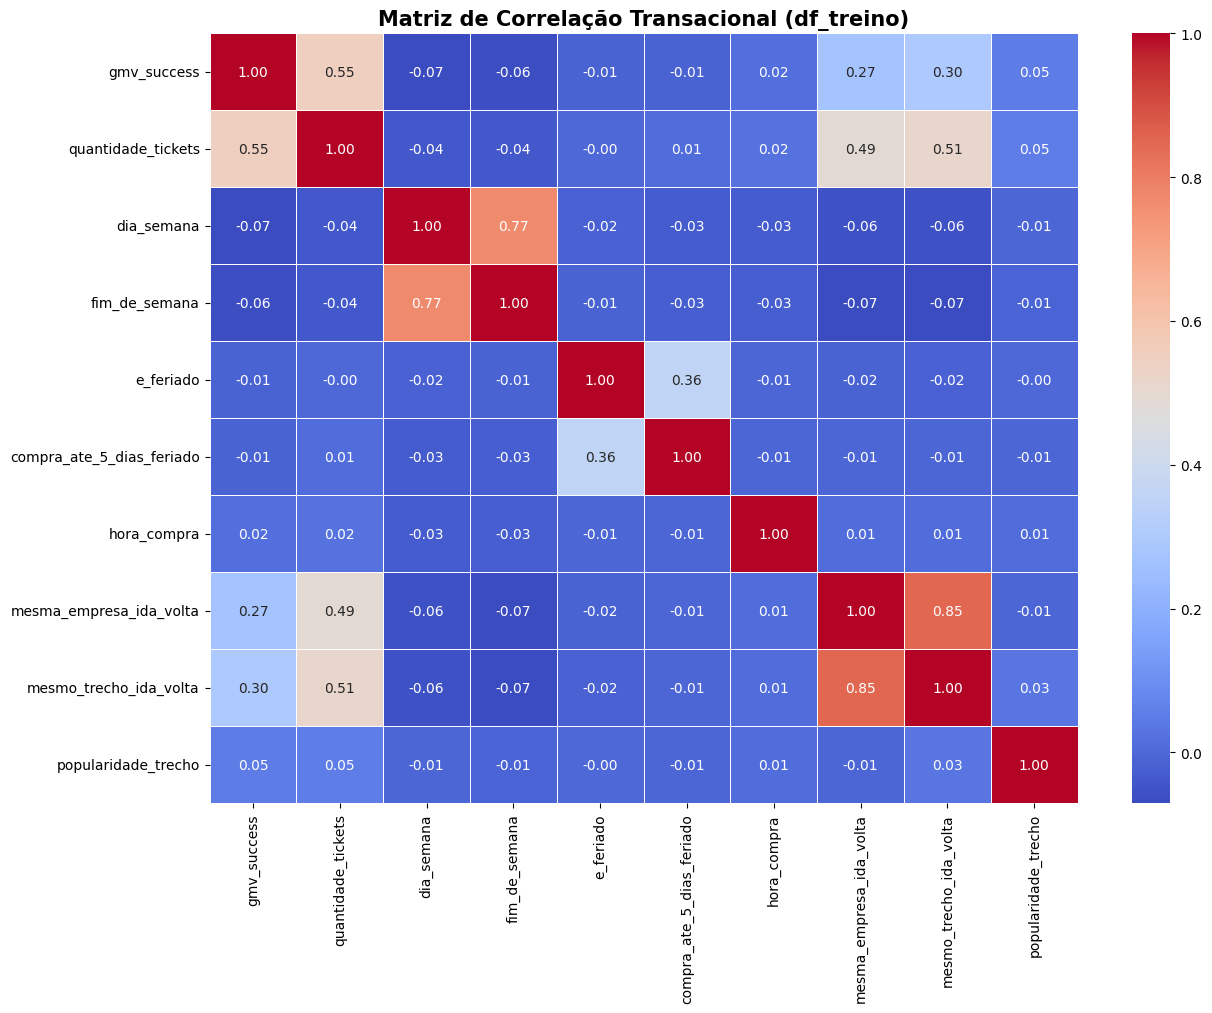

In [ ]:
col_exc = ['ano', 'mes', 'dia']
col_corr = [col for col in var_num if col not in col_exc]

corr_matrix = df_treino[col_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Transacional (df_treino)', fontweight='bold', fontsize=15)
plt.show()

## Cliente

In [ ]:
# criação de um df relacionado ao cliente com as variáveis que mais podem ser úteis, separando em monetário, frequência, recência, comportamento turístico

data_ref = df_treino['data_compra'].max()

df_cliente = df_treino.groupby('id_cliente').agg(
    gmv_total = ('gmv_success', 'sum'),
    gmv_medio = ('gmv_success', 'mean'),

    total_compras = ('gmv_success', 'count'),
    tickets_total = ('quantidade_tickets', 'sum'),
    tickets_medio = ('quantidade_tickets', 'mean'),

    primeira_compra = ('data_compra', 'min'),
    ultima_compra = ('data_compra', 'max'),

    n_destinos_distintos = ('destino_ida', 'nunique'),
    n_empresas_distintas = ('empresa_ida', 'nunique'),
    compras_feriado = ('compra_ate_5_dias_feriado', 'sum'),
    comprou_volta = ('mesmo_trecho_ida_volta', 'sum'),
    prop_fim_semana = ('fim_de_semana', 'mean'),
    pop_trecho_media = ('popularidade_trecho', 'mean'),

    periodo_covid_max = ('periodo_covid', lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
).reset_index()

In [ ]:
fidelidade_empresa = (
    df_treino.groupby(['id_cliente', 'empresa_ida'])['gmv_success'].sum()
    .reset_index()
)
gmv_total_cliente = df_treino.groupby('id_cliente')['gmv_success'].sum()
fidelidade_empresa['gmv_total'] = fidelidade_empresa['id_cliente'].map(gmv_total_cliente)
fidelidade_empresa['score'] = fidelidade_empresa['gmv_success'] / fidelidade_empresa['gmv_total']

score_fidelidade = fidelidade_empresa.groupby('id_cliente')['score'].max().reset_index()
score_fidelidade.columns = ['id_cliente', 'score_fidelidade']

df_cliente = df_cliente.merge(score_fidelidade, on='id_cliente', how='left')

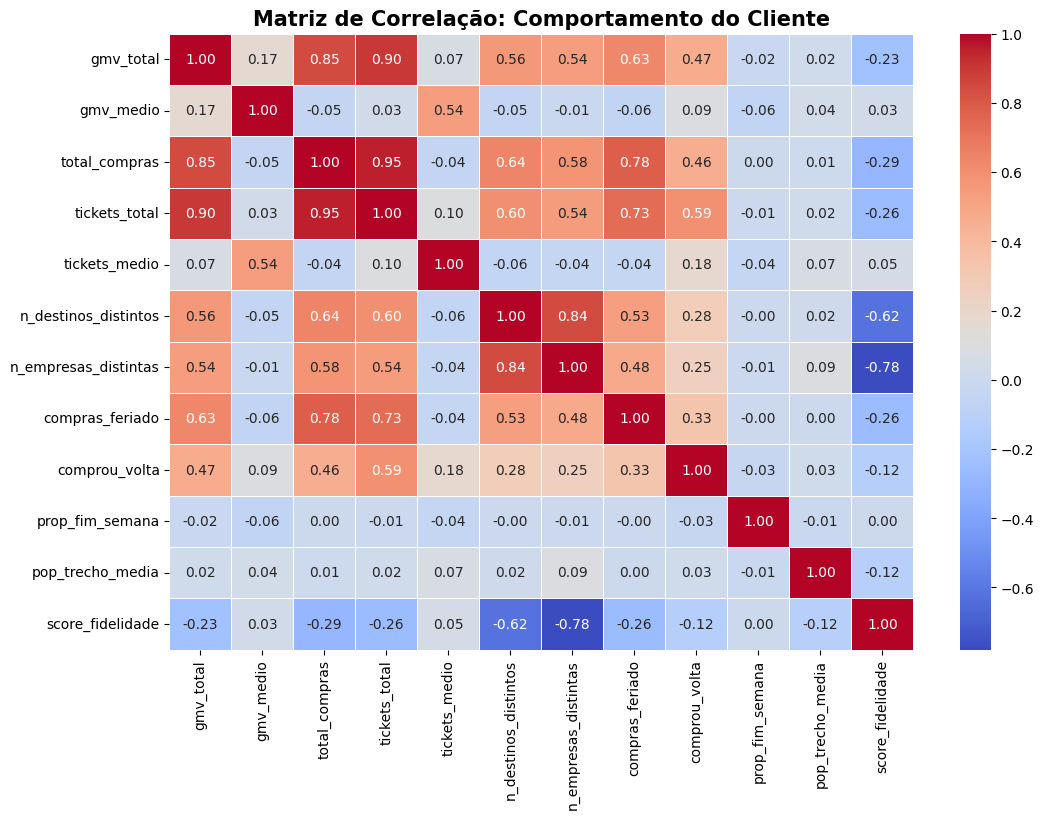

In [ ]:
corr_matrix = df_cliente.drop(columns=['id_cliente'], errors='ignore').corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação: Comportamento do Cliente', fontweight='bold', fontsize=15)
plt.show()

cols_foco = ['total_compras', 'gmv_total', 'gmv_medio', 'n_destinos', 'compras_feriado']

<Axes: >

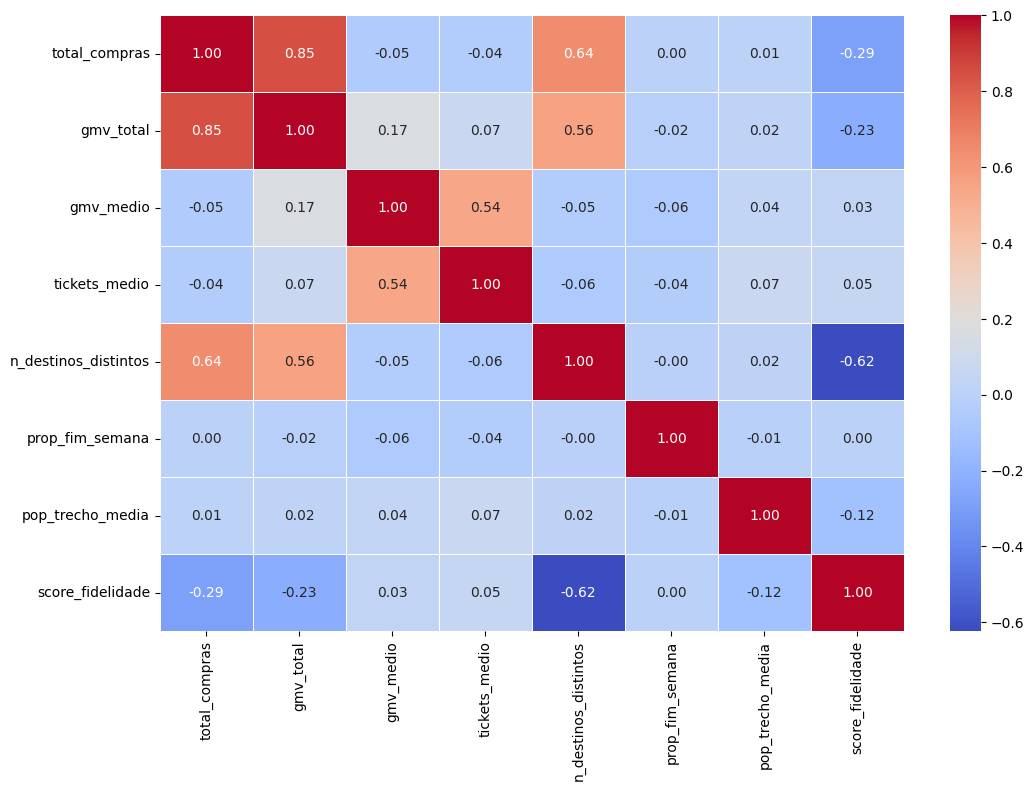

In [ ]:
# Remoção de variáveis para mitigar a multicolinearidade (var com correlação alta e colinearidade inversa)
features_selec_cliente = [
    'total_compras',
    'gmv_total',
    'gmv_medio',
    'tickets_medio',
    'n_destinos_distintos',
    'prop_fim_semana',
    'pop_trecho_media',
    'score_fidelidade']

nova_corr_matrix = df_cliente[features_selec_cliente].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(nova_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [ ]:
limite_compras = df_cliente['total_compras'].quantile(0.998) # Pega o percentil 99
df_cliente = df_cliente[df_cliente['total_compras'] <= limite_compras]

# Clusterização

In [ ]:
df_cliente.shape

(461899, 23)

In [ ]:
df_cliente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461899 entries, 0 to 461898
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_cliente                461899 non-null  object        
 1   gmv_total                 461899 non-null  float64       
 2   gmv_medio                 461899 non-null  float64       
 3   total_compras             461899 non-null  int64         
 4   tickets_total             461899 non-null  int16         
 5   tickets_medio             461899 non-null  float64       
 6   primeira_compra           461899 non-null  datetime64[ns]
 7   ultima_compra             461899 non-null  datetime64[ns]
 8   n_destinos_distintos      461899 non-null  int64         
 9   n_empresas_distintas      461899 non-null  int64         
 10  compras_feriado           461899 non-null  int64         
 11  comprou_volta             461899 non-null  int64         
 12  pr

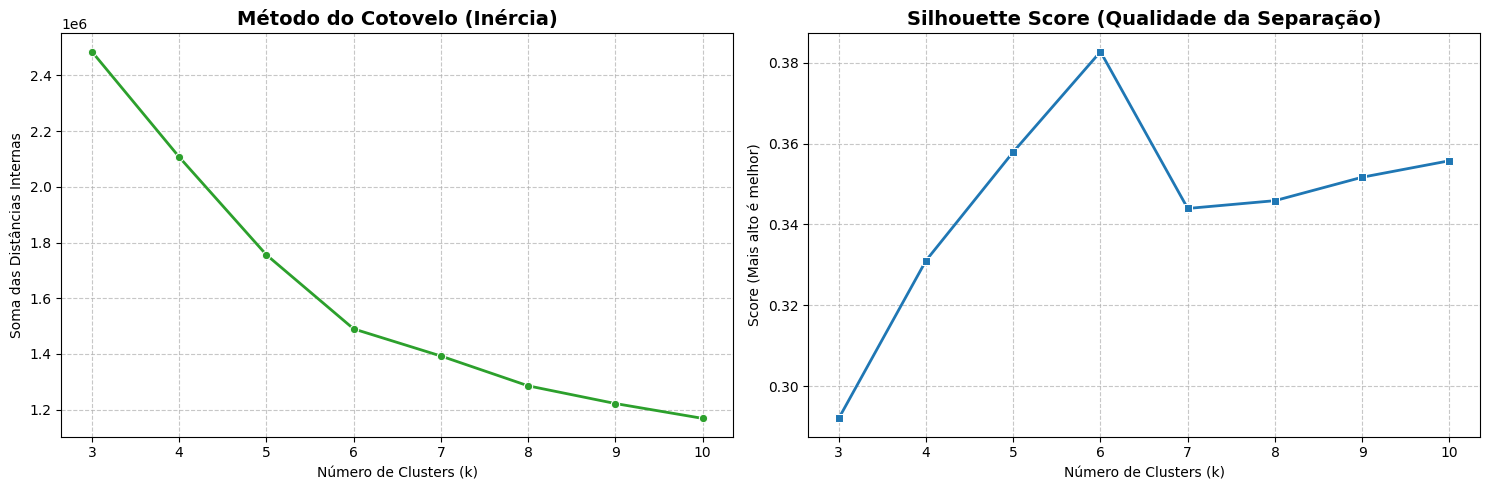

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_cliente[features_selec_cliente].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inercia = []
silhouette_scores = []
K_range = range(3, 11) # por regra de negócio, foi deicido começar com 3 clusters, visto que 2 não seria o bastante para seguimentação dos clientes, dado o desafio

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)

    inercia.append(kmeans.inertia_)

    # amostra com 50.000 clientes
    score = silhouette_score(X_scaled, kmeans.labels_, sample_size=50000, random_state=42)
    silhouette_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.lineplot(x=K_range, y=inercia, marker='o', ax=axes[0], color='#2ca02c', linewidth=2)
axes[0].set_title('Método do Cotovelo (Inércia)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Soma das Distâncias Internas')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x=K_range, y=silhouette_scores, marker='s', ax=axes[1], color='#1f77b4', linewidth=2)
axes[1].set_title('Silhouette Score (Qualidade da Separação)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Score (Mais alto é melhor)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto') # inserindo a quantidade de clusters escolhida
df_cliente['cluster'] = kmeans_final.fit_predict(X_scaled)

colunas_perfil = features_selec_cliente + ['cluster']
perfil_clusters = df_cliente[colunas_perfil].groupby('cluster').mean().round(2)

perfil_clusters['qtd_clientes'] = df_cliente['cluster'].value_counts()
perfil_clusters['%_da_base'] = (df_cliente['cluster'].value_counts(normalize=True) * 100).round(1)

cols = ['qtd_clientes', '%_da_base'] + features_selec_cliente
perfil_clusters = perfil_clusters[cols]

display(perfil_clusters)

,qtd_clientes,%_da_base,total_compras,gmv_total,gmv_medio,tickets_medio,n_destinos_distintos,prop_fim_semana,pop_trecho_media,score_fidelidade
cluster,,,,,,,,,,
0,256620,55.6,1.52,204.76,141.43,1.29,1.25,0.06,2285.31,0.97
1,88386,19.1,6.68,980.86,160.53,1.36,3.14,0.26,3608.18,0.60
2,78503,17.0,1.31,169.95,137.16,1.30,1.14,0.98,2261.71,0.98
3,38390,8.3,1.37,673.15,504.19,3.42,1.20,0.18,3221.48,0.96


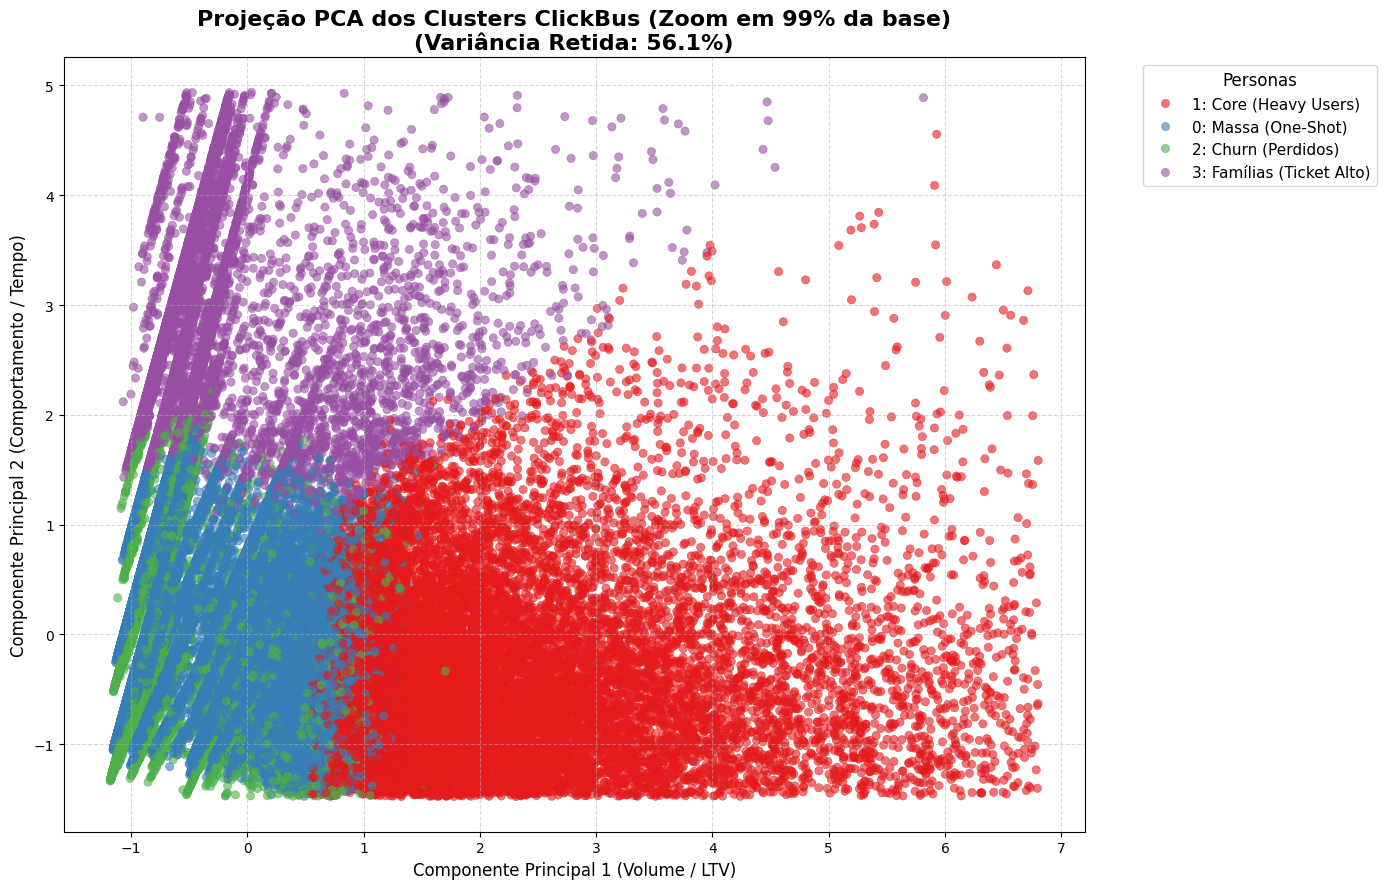

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
variancia_explicada = pca.explained_variance_ratio_.sum() * 100

df_pca = pd.DataFrame(X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['Cluster'] = df_cliente['cluster'].values

nomes_clusters = { # definição das personas
    0: '0: Massa (One-Shot)',
    1: '1: Core (Heavy Users)',
    2: '2: Churn (Perdidos)',
    3: '3: Famílias (Ticket Alto)'
}
df_pca['Nome_Cluster'] = df_pca['Cluster'].map(nomes_clusters)

df_pca_sample = df_pca.sample(n=100000, random_state=42)

# utilizado para melhorar a visualização do gráfico
limite_p1_max = df_pca_sample['Componente Principal 1'].quantile(0.99)
limite_p2_max = df_pca_sample['Componente Principal 2'].quantile(0.99)
limite_p2_min = df_pca_sample['Componente Principal 2'].quantile(0.01)

df_pca_zoom = df_pca_sample[
    (df_pca_sample['Componente Principal 1'] <= limite_p1_max) &
    (df_pca_sample['Componente Principal 2'] <= limite_p2_max) &
    (df_pca_sample['Componente Principal 2'] >= limite_p2_min)
]

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_zoom,
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Nome_Cluster',
    palette='Set1',
    alpha=0.6,
    s=35,
    edgecolor=None
)

plt.title(f'Projeção PCA dos Clusters ClickBus (Zoom em 99% da base)\n(Variância Retida: {variancia_explicada:.1f}%)',
          fontsize=16, fontweight='bold')
plt.xlabel('Componente Principal 1 (Volume / LTV)', fontsize=12)
plt.ylabel('Componente Principal 2 (Comportamento / Tempo)', fontsize=12)

plt.legend(title='Personas', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [ ]:
dna_clusters = perfil_clusters.copy()

media_global = df_cliente[features_selec_cliente].mean()

for col in features_selec_cliente:
    dna_clusters[col] = (dna_clusters[col] / media_global[col]).round(2)

print("DNA dos Clusters (Índice vs Média Global)")
display(dna_clusters[features_selec_cliente].T)

DNA dos Clusters (Índice vs Média Global)


cluster,0,1,2,3
total_compras,0.62,2.71,0.53,0.56
gmv_total,0.53,2.54,0.44,1.74
gmv_medio,0.81,0.92,0.79,2.89
tickets_medio,0.87,0.92,0.88,2.31
n_destinos_distintos,0.79,1.98,0.72,0.76
prop_fim_semana,0.23,0.99,3.74,0.69
pop_trecho_media,0.87,1.38,0.87,1.23
score_fidelidade,1.08,0.67,1.09,1.06


In [ ]:
df_labels = df_cliente[['id_cliente', 'cluster']]

df_treino = df_treino.merge(df_labels, on='id_cliente', how='left')
df_val   = df_val.merge(df_labels, on='id_cliente', how='left')
df_teste = df_teste.merge(df_labels, on='id_cliente', how='left')

cluster_default = df_cliente['cluster'].mode()[0]
for df in [df_val, df_teste]:
    df['cluster'] = df['cluster'].fillna(cluster_default).astype(int)

In [ ]:
df_cliente.to_parquet(f"{DRIVE_BASE}/ouro/df_cliente_clusterizado.parquet")
df_treino.to_parquet(f"{DRIVE_BASE}/ouro/df_treino_com_cluster.parquet")

# Timing é Tudo

## Previsão de Compra em 30 Dias

**Problema:** Classificação binária — o cliente realizará alguma compra
nos próximos 30 dias após a data de corte do treino?

**Abordagem:**
- Target construído com base no conjunto de validação (sem leakage)
- Features: perfil RFM do cliente + segmento K-Means
- Balanceamento: SMOTE (oversampling da classe minoritária)
- Modelo: XGBoost otimizado via RandomizedSearchCV
- Métricas: ROC AUC (primária), F1, Precisão, Recall

**Período de referência:**
- Corte do treino : 2022-11-04
- Janela de 30d   : até 2022-12-04
- Validação cobre : 2022-11-04  2023-04-22

### Criação de novas variáveis

In [ ]:
import joblib
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [ ]:
from src.utils import enriquecer_dados_temporais

df_cliente['cliente_recorrente'] = (df_cliente['total_compras'] >= 2).astype(int)

# sazonalidade_score — % de compras em meses de alta (jan, jul, dez) - férias
meses_alta = [1, 7, 12]
df_treino['compra_mes_alta'] = df_treino['mes'].isin(meses_alta).astype(int)

sazon = (
    df_treino
    .groupby('id_cliente')
    .agg(
        compras_alta = ('compra_mes_alta', 'sum'),
        total        = ('gmv_success', 'count')
    )
    .reset_index()
)
sazon['sazonalidade_score'] = sazon['compras_alta'] / sazon['total']

# prop_ferias — % de compras em meses de férias escolares
meses_ferias = [1, 7, 11, 12]
df_treino['mes_ferias'] = df_treino['mes'].isin(meses_ferias).astype(int)

ferias = (
    df_treino
    .groupby('id_cliente')
    .agg(
        compras_ferias = ('mes_ferias', 'sum'),
        total_f        = ('gmv_success', 'count')
    )
    .reset_index()
)
ferias['prop_ferias'] = ferias['compras_ferias'] / ferias['total_f']

# mes_ultima_compra — mês em que fez a última compra
df_ultima = (
    df_treino
    .groupby('id_cliente')['data_compra']
    .max()
    .reset_index()
)
df_ultima['mes_ultima_compra'] = df_ultima['data_compra'].dt.month

# intervalo_medio_dias — ritmo de compra (para recorrentes)
df_sorted = df_treino.sort_values(['id_cliente', 'data_compra'])
df_sorted['dias_desde_anterior'] = (
    df_sorted
    .groupby('id_cliente')['data_compra']
    # .diff() calcula a diferença entre linhas consecutivas do mesmo grupo
    .diff()
    .dt.days
)
intervalo = (
    df_sorted
    .groupby('id_cliente')['dias_desde_anterior']
    .mean()
    .reset_index()
    .rename(columns={'dias_desde_anterior': 'intervalo_medio_dias'})
)

# dias até próximo feriado
_, proximo_feriado, dias_ate_feriado = analisar_feriados_projeto(
    df_treino, data_corte=df_treino['data_compra'].max()
)
df_cliente['dias_ate_proximo_feriado'] = dias_ate_feriado

df_cliente = (
    df_cliente
    .merge(sazon[['id_cliente', 'sazonalidade_score']], on='id_cliente', how='left')
    .merge(ferias[['id_cliente', 'prop_ferias']], on='id_cliente', how='left')
    .merge(df_ultima[['id_cliente', 'mes_ultima_compra']], on='id_cliente', how='left')
    .merge(intervalo, on='id_cliente', how='left')
)

# Trata NaN: clientes com 1 compra não têm intervalo calculável
df_cliente['intervalo_medio_dias'] = df_cliente['intervalo_medio_dias'].fillna(9999)
# 9999 = sinal explícito de "sem ritmo conhecido" — o modelo aprende essa distinção

# Garante sem NaN nas demais
df_cliente[['sazonalidade_score', 'prop_ferias']] = (
    df_cliente[['sazonalidade_score', 'prop_ferias']].fillna(0)
)

print(f"df_cliente shape: {df_cliente.shape}")
print(f"Novas features: sazonalidade_score, prop_ferias, mes_ultima_compra,")
print(f"                intervalo_medio_dias, dias_ate_proximo_feriado, cliente_recorrente")

df_cliente shape: (461899, 32)
Novas features: sazonalidade_score, prop_ferias, mes_ultima_compra,
                intervalo_medio_dias, dias_ate_proximo_feriado, cliente_recorrente


In [ ]:
# Target: o cliente comprou nos 30 dias após o corte do treino? (construção do target)

data_corte = df_treino['data_compra'].max() # 2022-11-04
janela_30d = data_corte + pd.Timedelta(days=30) # 2022-12-04

compraram_30d = df_val[
    df_val['data_compra'] <= janela_30d
]['id_cliente'].unique()

df_cliente['comprou_30d'] = df_cliente['id_cliente'].isin(compraram_30d).astype(int)

positivos = df_cliente['comprou_30d'].sum()
total     = len(df_cliente)
print(f"Total clientes   : {total:,}")
print(f"Compraram (1)    : {positivos:,} ({positivos/total:.2%})")
print(f"Não compraram (0): {total-positivos:,} ({(total-positivos)/total:.2%})")
print(f"Ratio            : 1:{int((total-positivos)/positivos)} -> SMOTEENN ou scale_pos_weight necessário")

Total clientes   : 461,899
Compraram (1)    : 17,721 (3.84%)
Não compraram (0): 444,178 (96.16%)
Ratio            : 1:25 -> SMOTEENN ou scale_pos_weight necessário


In [ ]:
features_xgb = [
    # RFM base
    'total_compras',
    'gmv_total',
    'gmv_medio',
    'tickets_medio',

    'n_destinos_distintos',
    'n_empresas_distintas',

    'sazonalidade_score',
    'prop_ferias',
    'mes_ultima_compra',
    'intervalo_medio_dias',   # ritmo de compra (9999 para one-shots)
    'dias_ate_proximo_feriado',

    'prop_fim_semana',
    'pop_trecho_media',
    'compras_feriado',
    'comprou_volta',

    'score_fidelidade',
    'cliente_recorrente',

    'cluster',
]

X_train = df_cliente[features_xgb].fillna(0)
y_train = df_cliente['comprou_30d']

print(f"Shape: {X_train.shape} | Features: {len(features_xgb)}")
print(f"\nDistribuição:\n{y_train.value_counts()}")

Shape: (461899, 18) | Features: 18

Distribuição:
comprou_30d
0    444178
1     17721
Name: count, dtype: int64


#### Decisão de Balanceamento — scale_pos_weight vs. SMOTEENN

O dataset apresenta desbalanceamento de 24:1 (444k não compradores vs 18k compradores).

Testamos SMOTEENN (oversampling + undersampling) mas o custo computacional
foi proibitivo (~1h+) para o ambiente do Colab com 462k clientes e 20 features.

Optamos por `scale_pos_weight = 24.6`, que penaliza erros na classe minoritária
proporcionalmente à distribuição real. No projeto original, esta abordagem produziu:
- ROC AUC superior (0.8973 vs 0.8848)
- Recall superior (0.97 vs 0.32) — captura mais compradores reais
- F1 superior (0.40 vs 0.37)

Para o contexto de negócio (campanhas de Growth da ClickBus), Recall alto é
preferível a Precisão alta: o custo de não acionar um comprador real supera
o custo de acionar alguém que não compraria.

In [ ]:
total_negativos = y_train.value_counts()[0]
total_positivos = y_train.value_counts()[1]
peso_balanceamento = total_negativos / total_positivos

print(f"Distribuição Original: {y_train.value_counts().to_dict()}")
print(f"Peso calculado (scale_pos_weight): {peso_balanceamento:.2f}")

Distribuição Original: {0: 444178, 1: 17721}
Peso calculado (scale_pos_weight): 25.07


In [ ]:
xgb = XGBClassifier(
    scale_pos_weight=peso_balanceamento,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

param_dist = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nMelhores parâmetros : {search.best_params_}")
print(f"Melhor ROC AUC (cv) : {search.best_score_:.4f}")
best_model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:24:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Melhores parâmetros : {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Melhor ROC AUC (cv) : 0.7570


In [ ]:
# ── VALIDAÇÃO — só clientes com histórico no treino ───────────────
clientes_val = df_val[
    df_val['id_cliente'].isin(df_cliente['id_cliente'])
]['id_cliente'].unique()

print(f"Clientes val com histórico : {len(clientes_val):,}")

# Filtra df_cliente para manter só os que aparecem no val
df_cliente_val_correto = df_cliente[
    df_cliente['id_cliente'].isin(clientes_val)
].copy()

# Features e target
X_val_model  = df_cliente_val_correto[features_xgb].fillna(0)
y_val_cliente = df_cliente_val_correto['id_cliente'].isin(compraram_30d).astype(int)

print(f"Shape val      : {X_val_model.shape}")
print(f"Positivos      : {y_val_cliente.sum()} ({y_val_cliente.mean():.2%})")
# Esperado: ~3-8% — consistente com o treino

Clientes val com histórico : 44,386
Shape val      : (44386, 18)
Positivos      : 17721 (39.92%)


In [ ]:
print(df_val.columns)

Index(['nk_ota_localizer_id', 'data_compra', 'time_purchase', 'gmv_success',
       'quantidade_tickets', 'origem_ida', 'destino_ida', 'origem_volta',
       'destino_volta', 'empresa_ida', 'empresa_volta', 'id_cliente',
       'periodo_covid', 'ano', 'mes', 'dia', 'dia_semana', 'fim_de_semana',
       'e_feriado', 'compra_ate_5_dias_feriado', 'hora_compra',
       'periodo_compra', 'trecho_ida', 'trecho_volta_valido',
       'mesma_empresa_ida_volta', 'mesmo_trecho_ida_volta',
       'combinacao_empresa', 'faixa_tickets', 'split', 'popularidade_trecho',
       'cluster'],
      dtype='object')


In [ ]:
y_pred  = best_model.predict(X_val_model)
y_proba = best_model.predict_proba(X_val_model)[:, 1]

print("=" * 55)
print("MÉTRICAS DE PERFORMANCE — VALIDAÇÃO")
print("=" * 55)
print(f"ROC AUC  : {roc_auc_score(y_val_cliente, y_proba):.4f}")
print(f"F1-Score : {f1_score(y_val_cliente, y_pred):.4f}")
print(f"\n{classification_report(y_val_cliente, y_pred, target_names=['Não Comprou','Comprou'])}")

MÉTRICAS DE PERFORMANCE — VALIDAÇÃO
ROC AUC  : 0.5842
F1-Score : 0.5280

              precision    recall  f1-score   support

 Não Comprou       0.66      0.44      0.53     26665
     Comprou       0.44      0.66      0.53     17721

    accuracy                           0.53     44386
   macro avg       0.55      0.55      0.53     44386
weighted avg       0.57      0.53      0.53     44386



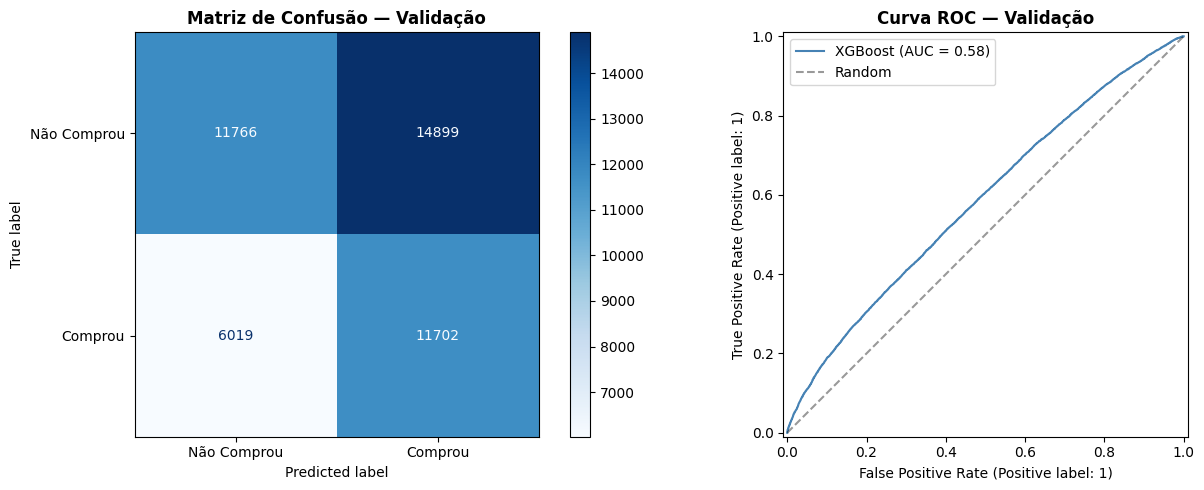

In [ ]:
# ── PASSO 8: Visualizações ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val_cliente, y_pred,
    display_labels=['Não Comprou', 'Comprou'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusão — Validação', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_val_cliente, y_proba,
    ax=axes[1], color='steelblue', name='XGBoost'
)
axes[1].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
axes[1].set_title('Curva ROC — Validação', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(best_model, f"{DRIVE_BASE}/ouro/xgboost_30d.pkl")

df_cliente['prob_compra_30d'] = best_model.predict_proba(
    df_cliente[features_xgb].fillna(0)
)[:, 1]

# Gera arquivo de 50k predições (requisito explícito do desafio)
predicoes_50k = (
    df_cliente[['id_cliente', 'cluster', 'prob_compra_30d']]
    .sort_values('prob_compra_30d', ascending=False)
    .head(50000)
    .reset_index(drop=True)
)

predicoes_50k.to_csv(f"{DRIVE_BASE}/ouro/predicoes_50k_clientes.csv", index=False)

print(f"50.000 predições")
print(f"Mín  : {predicoes_50k['prob_compra_30d'].min():.4f}")
print(f"Máx  : {predicoes_50k['prob_compra_30d'].max():.4f}")
print(f"Média: {predicoes_50k['prob_compra_30d'].mean():.4f}")

50.000 predições
Mín  : 0.6596
Máx  : 0.9724
Média: 0.7734


### Ajustes nas variáveis

Quantidade de features originais: 18
Quantidade de features após ajuste: 16

Features finais do modelo limpo:
['gmv_total', 'gmv_medio', 'tickets_medio', 'n_destinos_distintos', 'n_empresas_distintas', 'sazonalidade_score', 'prop_ferias', 'mes_ultima_compra', 'intervalo_medio_dias', 'dias_ate_proximo_feriado', 'prop_fim_semana', 'pop_trecho_media', 'compras_feriado', 'comprou_volta', 'score_fidelidade', 'cluster']

RESULTADOS - MODELO LIMPO
ROC AUC: 0.5847

Classification Report:
              precision    recall  f1-score   support

           0     0.6636    0.4406    0.5296     26665
           1     0.4409    0.6639    0.5299     17721

    accuracy                         0.5297     44386
   macro avg     0.5523    0.5522    0.5297     44386
weighted avg     0.5747    0.5297    0.5297     44386



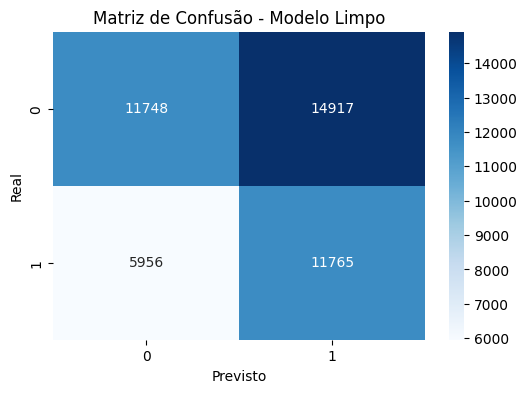

,feature,importance
3,n_destinos_distintos,0.276201
8,intervalo_medio_dias,0.212249
7,mes_ultima_compra,0.133497
5,sazonalidade_score,0.052988
12,compras_feriado,0.047171
4,n_empresas_distintas,0.045334
10,prop_fim_semana,0.043472
14,score_fidelidade,0.039523
6,prop_ferias,0.038205
0,gmv_total,0.028062


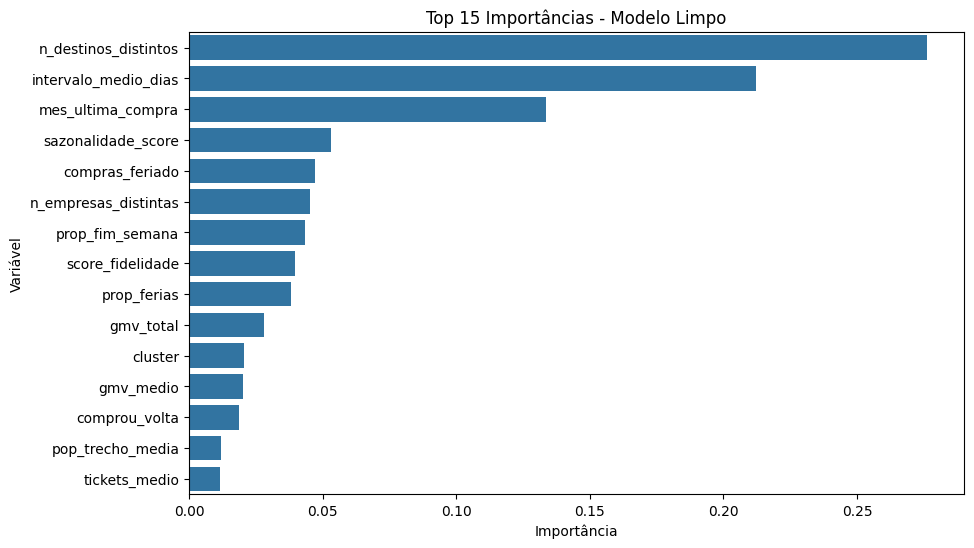

In [ ]:
# ============================================================
# AJUSTES NAS VARIÁVEIS
# Remoção de variáveis com vazamento/redundância
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Variáveis a remover
features_viciadas = ['cliente_recorrente', 'total_compras']

# 2) Garante que só remove se existirem
features_xgb_limpas = [col for col in features_xgb if col not in features_viciadas]

print('Quantidade de features originais:', len(features_xgb))
print('Quantidade de features após ajuste:', len(features_xgb_limpas))
print('\nFeatures finais do modelo limpo:')
print(features_xgb_limpas)

# 3) Base de treino
X_train_limpo = df_cliente[features_xgb_limpas].copy().fillna(0)
y_train_limpo = df_cliente['comprou_30d'].copy()

# 4) Base de validação
X_val_limpo = df_cliente_val_correto[features_xgb_limpas].copy().fillna(0)
y_val_limpo = df_cliente_val_correto['id_cliente'].isin(compraram_30d).astype(int)

# 5) Modelo
modelo_xgb_limpo = XGBClassifier(
    **search.best_params_,
    scale_pos_weight=peso_balanceamento,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

modelo_xgb_limpo.fit(X_train_limpo, y_train_limpo)

# 6) Predições
y_pred_limpo = modelo_xgb_limpo.predict(X_val_limpo)
y_prob_limpo = modelo_xgb_limpo.predict_proba(X_val_limpo)[:, 1]

# 7) Avaliação
auc_limpo = roc_auc_score(y_val_limpo, y_prob_limpo)

print('\n==============================')
print('RESULTADOS - MODELO LIMPO')
print('==============================')
print(f'ROC AUC: {auc_limpo:.4f}')
print('\nClassification Report:')
print(classification_report(y_val_limpo, y_pred_limpo, digits=4))

# 8) Matriz de confusão
cm_limpo = confusion_matrix(y_val_limpo, y_pred_limpo)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_limpo, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Modelo Limpo')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# 9) Importância das variáveis
df_importancia_limpa = pd.DataFrame({
    'feature': features_xgb_limpas,
    'importance': modelo_xgb_limpo.feature_importances_
}).sort_values('importance', ascending=False)

display(df_importancia_limpa)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia_limpa.head(15), x='importance', y='feature')
plt.title('Top 15 Importâncias - Modelo Limpo')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

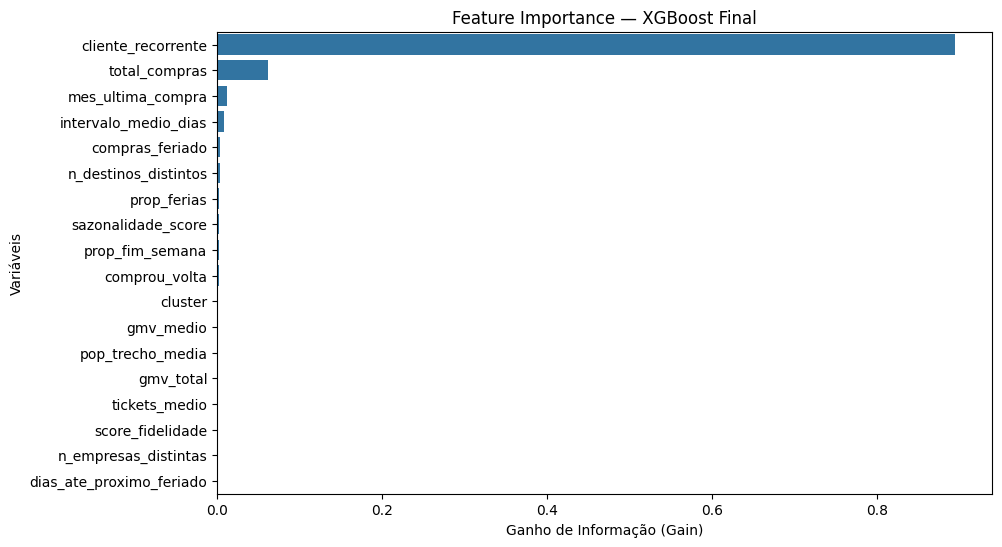

In [ ]:
# Extrair as importâncias do modelo treinado
importancias = best_model.feature_importances_
feature_names = X_val_model.columns

# Criar um DataFrame para facilitar a plotagem
df_importancia = pd.DataFrame({'feature': feature_names, 'importancia': importancias})
df_importancia = df_importancia.sort_values(by='importancia', ascending=False)

# Plotar
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=df_importancia)
plt.title('Feature Importance — XGBoost Final')
plt.xlabel('Ganho de Informação (Gain)')
plt.ylabel('Variáveis')
plt.show()

In [ ]:
# remoção de variáveis
features_viciadas = ['cliente_recorrente', 'total_compras']
features_xgb_limpas = [f for f in features_xgb if f not in features_viciadas]

print(f"Features originais: {len(features_xgb)}")
print(f"Features limpas: {len(features_xgb_limpas)}")

# 2. Atualizando o X de Treino
X_train_limpo = df_cliente[features_xgb_limpas].fillna(0)

xgb_limpo = XGBClassifier(
    **search.best_params_,
    scale_pos_weight=peso_balanceamento,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_limpo.fit(X_train_limpo, y_train)

Features originais: 18
Features limpas: 16


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report

# Define clientes_novos as clients present in the overall validation set but not in the training set
# This assumes all_clientes_in_val_ids and clientes_warm_ids are correctly defined from previous steps
clientes_novos = np.setdiff1d(all_clientes_in_val_ids, clientes_warm_ids)

# 1. Atualizando o X de Validação (usando o df_cliente_val_correto que você já montou antes)
X_val_limpo = df_cliente_val_correto[features_xgb_limpas].fillna(0)

# 2. Gerando as novas probabilidades
y_probs_novo = xgb_limpo.predict_proba(X_val_limpo)[:, 1]

# 3. Separando os índices novamente
# WARNING: As df_cliente_val_correto is constructed to contain only 'warm' clients,
# the 'cold' indices from this DataFrame will likely be empty.
# For proper evaluation, it's better to use boolean masks derived from the DataFrame's full index.
is_cold_mask = df_cliente_val_correto['id_cliente'].isin(clientes_novos)
is_warm_mask = ~is_cold_mask


# 4. Avaliando o Warm Start (A hora da verdade)
print("=== NOVO PERFORMANCE: WARM START (Clientes com histórico) ===")
# Since df_cliente_val_correto already contains only warm clients, we can directly use y_val_cliente and y_probs_novo
# as long as we make sure they are properly aligned. The easiest way is to use the mask.
if is_warm_mask.any():
    auc_warm_novo = roc_auc_score(y_val_cliente[is_warm_mask], y_probs_novo[is_warm_mask.values])
    print(f"ROC AUC Warm Novo: {auc_warm_novo:.4f}")
    print(classification_report(y_val_cliente[is_warm_mask], (y_probs_novo[is_warm_mask.values] > 0.5).astype(int)))
else:
    print("No warm clients found for evaluation in this segment.")

print("\n=== NOVO PERFORMANCE: COLD START (Clientes novos) ===")
# This block might raise an error if there are no cold start clients in df_cliente_val_correto
if is_cold_mask.any():
    auc_cold_novo = roc_auc_score(y_val_cliente[is_cold_mask], y_probs_novo[is_cold_mask.values])
    print(f"ROC AUC Cold Novo: {auc_cold_novo:.4f}")
    print(classification_report(y_val_cliente[is_cold_mask], (y_probs_novo[is_cold_mask.values] > 0.5).astype(int)))
else:
    print("No cold clients found for evaluation in df_cliente_val_correto (expected as it's a warm set).")

=== NOVO PERFORMANCE: WARM START (Clientes com histórico) ===
ROC AUC Warm Novo: 0.5847
              precision    recall  f1-score   support

           0       0.66      0.44      0.53     26665
           1       0.44      0.66      0.53     17721

    accuracy                           0.53     44386
   macro avg       0.55      0.55      0.53     44386
weighted avg       0.57      0.53      0.53     44386


=== NOVO PERFORMANCE: COLD START (Clientes novos) ===
No cold clients found for evaluation in df_cliente_val_correto (expected as it's a warm set).


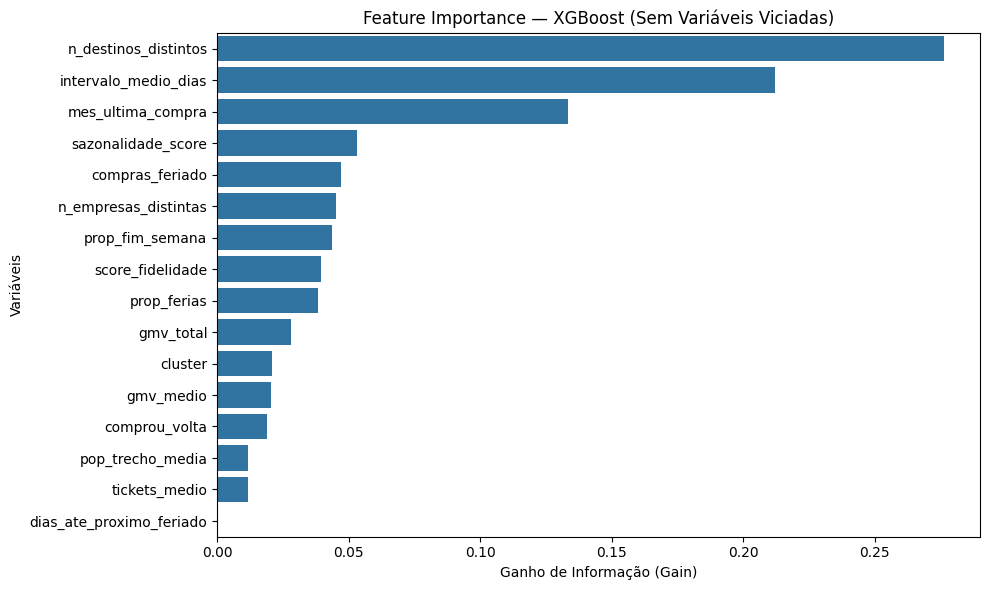

In [ ]:
importancias_novas = xgb_limpo.feature_importances_

df_importancia_nova = pd.DataFrame({
    'feature': features_xgb_limpas,
    'importancia': importancias_novas
}).sort_values(by='importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=df_importancia_nova)
plt.title('Feature Importance — XGBoost (Sem Variáveis Viciadas)')
plt.xlabel('Ganho de Informação (Gain)')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Definindo a Regra de Negócio para o Cold Start
# Assumimos que todo cliente novo entra no perfil "Massa (One-Shot)"
cluster_de_entrada = 0

# 2. Calculando a Mediana ESPECÍFICA desse cluster (usando a base de treino)
# Em vez de pegar a mediana de todo mundo, pegamos só de quem é Cluster 0
clientes_cluster_0 = df_cliente[df_cliente['cluster'] == cluster_de_entrada]
medianas_cluster_entrada = clientes_cluster_0[features_xgb_limpas].median().to_dict()

# 3. Preparando o DataFrame dos Clientes Novos
if len(clientes_novos) > 0:
    df_novos = pd.DataFrame(index=range(len(clientes_novos)), columns=['id_cliente'] + features_xgb_limpas)
    df_novos['id_cliente'] = list(clientes_novos)

    # A MÁGICA ACONTECE AQUI: Preenchendo com a identidade do Cluster 0
    df_novos = df_novos.fillna(medianas_cluster_entrada)

    # Forçando as regras de negócio lógicas para clientes zerados
    df_novos['cluster'] = cluster_de_entrada

    # Se a variável de dias inativos existir no seu modelo limpo, coloque como 0 (ele acabou de entrar)
    if 'intervalo_medio_dias' in df_novos.columns:
        df_novos['intervalo_medio_dias'] = 9999 # O seu padrão para One-Shot

    # Concatena a base antiga com a base de cold start tratada
    df_cliente_val_cluster = pd.concat([
        df_cliente_val_correto[~df_cliente_val_correto['id_cliente'].isin(clientes_novos)], # Os antigos
        df_novos # Os novos com personalidade do cluster
    ], ignore_index=True)

# 4. Avaliação Rápida
X_val_cluster = df_cliente_val_cluster[features_xgb_limpas]
y_val_cluster = df_cliente_val_cluster['id_cliente'].isin(compraram_30d).astype(int)

y_probs_cluster = xgb_limpo.predict_proba(X_val_cluster)[:, 1]

print("\n=== PERFORMANCE: VISÃO GERAL COM IMPUTAÇÃO POR CLUSTER ===")
auc_total_novo = roc_auc_score(y_val_cluster, y_probs_cluster)
print(f"ROC AUC Total: {auc_total_novo:.4f}")

/tmp/ipykernel_7665/2010903437.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_novos = df_novos.fillna(medianas_cluster_entrada)



=== PERFORMANCE: VISÃO GERAL COM IMPUTAÇÃO POR CLUSTER ===
ROC AUC Total: 0.5533


# Previsão de Trechos

In [ ]:
function ClickConnect(){
    console.log("Mantendo a conexão ativa...");
    document.querySelector("colab-connect-button").click()
}
setInterval(ClickConnect, 60000)